# Final Predictions & Export

This notebook loads the selected best model, generates predictions on the test set, and formats the output CSV according to the submission guidelines. We also generate the presentation visuals (Confusion Matrix & Feature Importance).

In [8]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import joblib
from sklearn.pipeline import Pipeline
import seaborn as sns
# Ensure src is accessible
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.cost_matrix import CLASSES


In [2]:
# Load Model and Test Data
model_path = repo_root / "models" / "best_model.pkl"
pipeline = joblib.load(model_path)

test_path = repo_root / "data" / "processed" / "test_processed.csv"
test_df = pd.read_csv(test_path)
X_test = test_df.drop(columns=["subject_id"])
patient_ids = test_df["subject_id"]


In [3]:
# Generate Predictions
probs = pipeline.predict_proba(X_test)
preds = pipeline.predict(X_test)

output_df = pd.DataFrame({
    "Patient ID": patient_ids,
    "Predicted Triage": preds,
    "RED Probability": probs[:, 0],
    "YELLOW Probability": probs[:, 1],
    "GREEN Probability": probs[:, 2],
    "BLACK Probability": probs[:, 3]
})

out_csv_path = repo_root / "outputs" / "CodeRed_MM26ML03.csv"
output_df.to_csv(out_csv_path, index=False)
print(f"Saved predictions to {out_csv_path}")


Saved predictions to c:\Projects\Modeling Minds\CodeRed\outputs\CodeRed_MM26ML03.csv


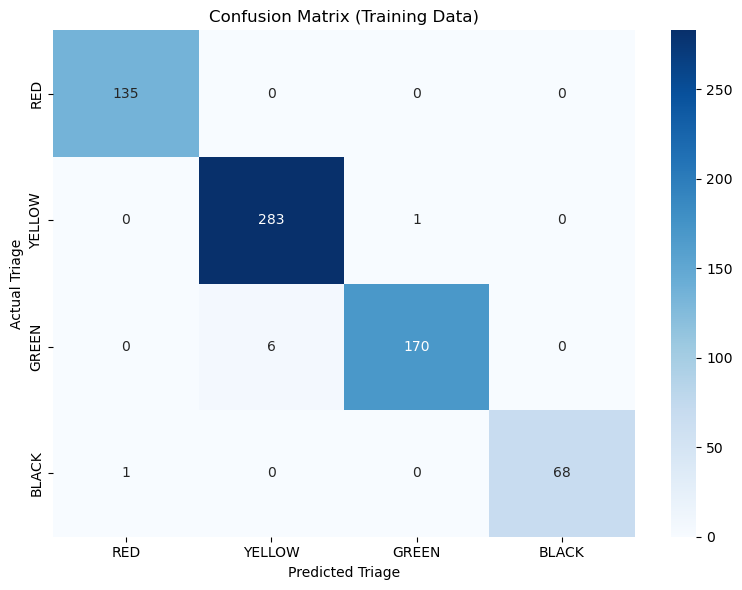

In [9]:
# Generate Confusion Matrix (on training data for presentation)
train_path = repo_root / "data" / "processed" / "train_processed.csv"
train_df = pd.read_csv(train_path)
X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]
y_train_pred = pipeline.predict(X_train)

cm = confusion_matrix(y_train, y_train_pred, labels=CLASSES)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted Triage")
plt.ylabel("Actual Triage")
plt.title("Confusion Matrix (Training Data)")
plt.tight_layout()
cm_path = repo_root / "outputs" / "confusion_matrix.png"
plt.savefig(cm_path)
plt.show()


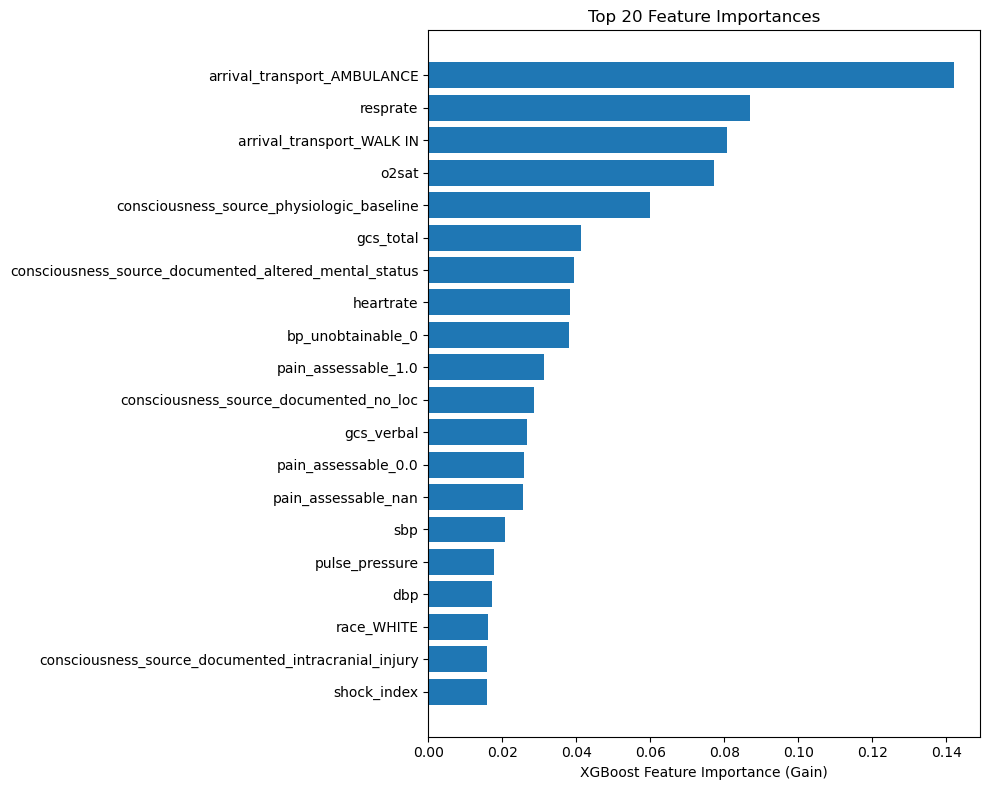

In [10]:
# Generate Feature Importance
xgb_model = pipeline.base_estimator
importances = xgb_model.feature_importances_
features = X_train.columns
indices = np.argsort(importances)[::-1]
top_n = 20
top_indices = indices[:top_n]

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), importances[top_indices][::-1], align="center")
plt.yticks(range(top_n), [features[i] for i in top_indices][::-1])
plt.xlabel("XGBoost Feature Importance (Gain)")
plt.title(f"Top {top_n} Feature Importances")
plt.tight_layout()
fi_path = repo_root / "outputs" / "feature_importance.png"
plt.savefig(fi_path)
plt.show()


In [3]:
%pip install -r "../requirements.txt"


  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)
Note: you may need to restart the kernel to use updated packages.
